# Weekend 2: 리랭킹과 답변 품질 평가 — Solution

---
## 환경 설정 및 데이터 준비

In [1]:
# 환경 설정
import os, json, time, re, math
import numpy as np
import pandas as pd
from collections import Counter
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.vectorstores import FAISS

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
MODEL = "gpt-4o-mini"

print("✅ 환경 설정 완료")

✅ 환경 설정 완료


In [2]:
# ============================================================
# ETF 금융 상품 샘플 데이터 (실습용)
# ============================================================
SAMPLE_ETF_DATA = [
    {"ticker": "KODEX200", "name": "KODEX 200", "category": "국내주식",
     "description": "KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK하이닉스 등 대형주 중심.",
     "expense_ratio": 0.15, "aum_billion": 58000, "risk_level": "중간"},
    {"ticker": "TIGER미국S&P500", "name": "TIGER 미국 S&P500", "category": "해외주식",
     "description": "미국 S&P 500 지수를 추종. 애플, 마이크로소프트 등 미국 대형주 투자.",
     "expense_ratio": 0.07, "aum_billion": 45000, "risk_level": "중간"},
    {"ticker": "KODEX배당가치", "name": "KODEX 배당가치", "category": "배당",
     "description": "고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목.",
     "expense_ratio": 0.30, "aum_billion": 8500, "risk_level": "낮음"},
    {"ticker": "TIGER반도체", "name": "TIGER 반도체", "category": "섹터",
     "description": "국내 반도체 산업 ETF. 삼성전자, SK하이닉스 등 반도체 관련주.",
     "expense_ratio": 0.40, "aum_billion": 12000, "risk_level": "높음"},
    {"ticker": "KODEX국고채3년", "name": "KODEX 국고채 3년", "category": "채권",
     "description": "한국 3년 만기 국고채에 투자하는 안정형 ETF.",
     "expense_ratio": 0.05, "aum_billion": 25000, "risk_level": "매우낮음"},
    {"ticker": "TIGER차이나CSI300", "name": "TIGER 차이나 CSI300", "category": "해외주식",
     "description": "중국 CSI 300 지수 추종. 상해/심천 대형주 투자.",
     "expense_ratio": 0.25, "aum_billion": 3500, "risk_level": "높음"},
    {"ticker": "KODEX골드선물", "name": "KODEX 골드선물(H)", "category": "원자재",
     "description": "금 선물 가격을 추종하는 원자재 ETF. 인플레이션 헤지 수단.",
     "expense_ratio": 0.68, "aum_billion": 5200, "risk_level": "중간"},
    {"ticker": "TIGER리츠부동산", "name": "TIGER 리츠부동산인프라", "category": "부동산",
     "description": "국내 리츠 및 부동산 인프라 기업에 투자. 배당 수익 추구.",
     "expense_ratio": 0.29, "aum_billion": 4100, "risk_level": "중간"},
    {"ticker": "KODEX2차전지", "name": "KODEX 2차전지산업", "category": "섹터",
     "description": "2차전지 관련 기업에 투자. LG에너지솔루션, 삼성SDI 등.",
     "expense_ratio": 0.45, "aum_billion": 18000, "risk_level": "높음"},
    {"ticker": "TIGER단기통안채", "name": "TIGER 단기통안채", "category": "채권",
     "description": "초단기 통안채에 투자. 파킹 용도로 활용되는 안전 자산.",
     "expense_ratio": 0.03, "aum_billion": 32000, "risk_level": "매우낮음"},
]

# 평가용 질의-정답 쌍
EVAL_QUERIES = [
    {"query": "안정적인 배당 ETF를 추천해주세요",
     "reference": "KODEX 배당가치 ETF를 추천합니다. 은행, 통신 등 고배당 가치주에 투자하며 리스크가 낮습니다. 수수료는 0.30%입니다.",
     "relevant_etfs": ["KODEX배당가치", "TIGER리츠부동산"]},
    {"query": "미국 주식에 투자하고 싶어요",
     "reference": "TIGER 미국 S&P500 ETF를 추천합니다. 애플, 마이크로소프트 등 미국 대형주에 투자하며 수수료가 0.07%로 저렴합니다.",
     "relevant_etfs": ["TIGER미국S&P500"]},
    {"query": "원금 손실 위험이 적은 ETF는?",
     "reference": "TIGER 단기통안채 ETF를 추천합니다. 초단기 통안채에 투자하여 원금 손실 위험이 매우 낮으며 수수료도 0.03%입니다.",
     "relevant_etfs": ["KODEX국고채3년", "TIGER단기통안채"]},
    {"query": "반도체 섹터에 투자하려면?",
     "reference": "TIGER 반도체 ETF를 추천합니다. 삼성전자, SK하이닉스 등 반도체 관련주에 집중 투자합니다. 리스크가 높으니 주의하세요.",
     "relevant_etfs": ["TIGER반도체"]},
    {"query": "인플레이션 헤지 방법이 있을까요?",
     "reference": "KODEX 골드선물(H) ETF를 고려해보세요. 금 선물 가격을 추종하여 인플레이션 헤지 수단으로 활용됩니다.",
     "relevant_etfs": ["KODEX골드선물"]},
    {"query": "중국 시장에 투자하는 ETF는?",
     "reference": "TIGER 차이나 CSI300 ETF가 있습니다. 상해/심천 대형주에 투자하지만 리스크가 높으니 신중하게 투자하세요.",
     "relevant_etfs": ["TIGER차이나CSI300"]},
]

print(f"✅ ETF 데이터 {len(SAMPLE_ETF_DATA)}개, 평가 질의 {len(EVAL_QUERIES)}개 준비 완료")

✅ ETF 데이터 10개, 평가 질의 6개 준비 완료


In [4]:
# Weekend 1 체크포인트 복원
import pickle, os, json
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

checkpoint_path = "project2_data/checkpoints/weekend1.pkl"
vs_path = "project2_data/vectorstore/faiss_baseline"

if os.path.exists(vs_path):
    vs = FAISS.load_local(vs_path, embeddings, allow_dangerous_deserialization=True)
    with open("project2_data/raw/etf_documents.json") as f:
        etf_docs = json.load(f)
    print(f"✅ 체크포인트 복원: 벡터 스토어 {vs.index.ntotal}개 문서")
else:
    from langchain_core.documents import Document
    docs = []
    etf_docs = {}
    for etf in SAMPLE_ETF_DATA:
        content = f"{etf['name']} ({etf['ticker']}): {etf['description']} 카테고리: {etf['category']}, 수수료: {etf['expense_ratio']}%, 리스크: {etf['risk_level']}"
        docs.append(Document(page_content=content, metadata={"ticker": etf["ticker"]}))
        etf_docs[etf["ticker"]] = {"name": etf["name"], "content": content, "category": etf["category"]}

    vs = FAISS.from_documents(docs, embeddings)
    print(f"✅ 새로 구축: 벡터 스토어 {vs.index.ntotal}개 문서")

# 하이브리드 검색 구성
from rank_bm25 import BM25Okapi

all_contents = [etf_docs[k]["content"] for k in etf_docs]
all_keys = list(etf_docs.keys())
bm25 = BM25Okapi([doc.split() for doc in all_contents])

def hybrid_search(query, k=5, alpha=0.5):
    """BM25 + 벡터 하이브리드 검색 (RRF)"""
    vec_results = vs.similarity_search_with_score(query, k=k)
    vec_ids = [(doc.metadata.get("ticker", ""), score) for doc, score in vec_results]

    bm25_scores = bm25.get_scores(query.split())
    bm25_ranked = sorted(enumerate(bm25_scores), key=lambda x: x[1], reverse=True)[:k]
    bm25_ids = [(all_keys[idx], score) for idx, score in bm25_ranked]

    rrf_scores = {}
    for rank, (doc_id, _) in enumerate(vec_ids):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + alpha / (rank + 60)
    for rank, (doc_id, _) in enumerate(bm25_ids):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + (1 - alpha) / (rank + 60)

    sorted_results = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return [(doc_id, rrf_scores[doc_id], etf_docs.get(doc_id, {}).get("content", "")) for doc_id, _ in sorted_results]

# 테스트
results = hybrid_search("안정적인 배당 ETF", k=3)
for doc_id, score, content in results:
    print(f"  [{doc_id}] score={score:.4f} | {content[:60]}...")

✅ 새로 구축: 벡터 스토어 10개 문서
  [KODEX배당가치] score=0.0165 | KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 ...
  [KODEX200] score=0.0161 | KODEX 200 (KODEX200): KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK...
  [TIGER리츠부동산] score=0.0083 | TIGER 리츠부동산인프라 (TIGER리츠부동산): 국내 리츠 및 부동산 인프라 기업에 투자. 배당 수익 추...


---
## 실습 1: Hit Rate 계산

In [5]:
# ✅ 정답
def hit_rate(eval_data, search_fn, k=5):
    hits = 0
    for item in eval_data:
        results = search_fn(item["query"], k=k)
        found_ids = [r[0] for r in results]
        if any(etf in found_ids for etf in item["relevant_etfs"]):
            hits += 1
    return hits / len(eval_data)

for k in [3, 5]:
    hr = hit_rate(EVAL_QUERIES, hybrid_search, k=k)
    print(f"Hit Rate@{k}: {hr:.3f}")

Hit Rate@3: 1.000
Hit Rate@5: 1.000


---
## 실습 2: RAG 답변 생성과 temperature 비교

In [8]:
# RAG 답변 생성 파이프라인
def ask_etf(query, k=3, verbose=False):
    """ETF 추천 RAG 파이프라인"""
    # 1) 검색
    results = hybrid_search(query, k=k)
    context = "\n\n".join([
        f"[{doc_id}] {content}" for doc_id, score, content in results
    ])

    # 2) LLM 답변 생성
    _llm = ChatOpenAI(model=MODEL, temperature=0)
    answer = _llm.invoke([
        SystemMessage(content="ETF 전문가입니다. 검색된 문서만을 근거로 답변하세요. 추측하지 마세요."),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {query}")
    ]).content

    if verbose:
        print(f"Q: {query}")
        print(f"검색: {[r[0] for r in results]}")
        print(f"A: {answer[:200]}...")
    return answer

# 테스트: 전체 평가 질의에 대해 답변 생성
answers = {}
for item in EVAL_QUERIES:
    answer = ask_etf(item["query"])
    answers[item["query"]] = answer
    print(f"Q: {item['query'][:30]}...")
    print(f"A: {answer[:100]}...\n")

print(f"✅ {len(answers)}개 답변 생성 완료")

Q: 안정적인 배당 ETF를 추천해주세요...
A: 안정적인 배당 ETF로는 다음 두 가지를 추천합니다:

1. **KODEX 배당가치**: 고배당 가치주 중심으로 구성되어 있으며, 은행과 통신 등 배당 수익률이 높은 종목에 투자합...

Q: 미국 주식에 투자하고 싶어요...
A: 미국 주식에 투자하고 싶다면, TIGER 미국 S&P500 ETF를 고려해볼 수 있습니다. 이 ETF는 미국 S&P 500 지수를 추종하며, 애플, 마이크로소프트 등 미국 대형주에...

Q: 원금 손실 위험이 적은 ETF는?...
A: 원금 손실 위험이 적은 ETF는 KODEX 국고채 3년 (KODEX국고채3년)입니다. 이 ETF는 한국 3년 만기 국고채에 투자하며, 리스크가 매우 낮습니다....

Q: 반도체 섹터에 투자하려면?...
A: 반도체 섹터에 투자하려면 TIGER 반도체 ETF를 고려할 수 있습니다. 이 ETF는 삼성전자, SK하이닉스 등 반도체 관련 주식에 투자하며, 수수료는 0.4%로 설정되어 있습니다...

Q: 인플레이션 헤지 방법이 있을까요?...
A: 인플레이션 헤지 방법 중 하나로 KODEX 골드선물 ETF를 고려할 수 있습니다. 이 ETF는 금 선물 가격을 추종하며, 인플레이션에 대한 헤지 수단으로 사용됩니다....

Q: 중국 시장에 투자하는 ETF는?...
A: 중국 시장에 투자하는 ETF는 TIGER 차이나 CSI300 (TIGER차이나CSI300)입니다. 이 ETF는 중국 CSI 300 지수를 추종하며, 상해 및 심천 대형주에 투자합니...

✅ 6개 답변 생성 완료


In [9]:
# ✅ 정답
import time

def ask_etf_v2(query, k=3, temperature=0, max_tokens=500):
    results = hybrid_search(query, k=k)
    context = "\n".join([f"[{did}] {c}" for did, _, c in results])
    start = time.time()
    _llm = ChatOpenAI(model=MODEL, temperature=temperature, max_tokens=max_tokens)
    answer = _llm.invoke([
        SystemMessage(content="ETF 전문가입니다."),
        HumanMessage(content=f"문서:\n{context}\n\n질문: {query}")
    ]).content
    elapsed = time.time() - start
    return answer, elapsed

q = "안정적인 배당 ETF를 추천해주세요"
a0, t0 = ask_etf_v2(q, temperature=0)
a7, t7 = ask_etf_v2(q, temperature=0.7)
print(f"temp=0: {len(a0)}자, {t0:.2f}초")
print(f"temp=0.7: {len(a7)}자, {t7:.2f}초")

temp=0: 317자, 4.46초
temp=0.7: 381자, 6.23초


---
## 실습 3: 리랭킹 전후 Hit Rate 비교

In [10]:
# LLM 기반 Reranking
import json

def llm_rerank(query, documents, top_k=3):
    """LLM으로 검색 결과를 질의 관련성 순으로 재정렬"""
    doc_list = "\n".join([
        f"[{i}] {doc_id}: {content[:150]}"
        for i, (doc_id, score, content) in enumerate(documents)
    ])

    _llm = ChatOpenAI(model=MODEL, temperature=0).bind(
        response_format={"type": "json_object"}
    )
    response = _llm.invoke([
        SystemMessage(content="ETF 검색 결과를 질의 관련성 순으로 재정렬하는 전문가입니다."),
        HumanMessage(content=f"""질문: {query}

검색 결과:
{doc_list}

위 검색 결과를 질문과의 관련성 순으로 정렬하세요.
각 문서에 1-10점 관련성 점수를 부여하세요.
JSON 형식으로 응답: {{"rankings": [{{"index": 0, "score": 9, "reason": "이유"}}]}}""")
    ])

    try:
        result = json.loads(response.content)
        rankings = result if isinstance(result, list) else result.get("rankings", result.get("results", []))
        rankings.sort(key=lambda x: x.get("score", 0), reverse=True)
        reranked = []
        for r in rankings[:top_k]:
            idx = r["index"]
            if 0 <= idx < len(documents):
                doc_id, _, content = documents[idx]
                reranked.append((doc_id, r["score"], content))
        return reranked
    except Exception as e:
        print(f"⚠️ 리랭킹 실패: {e}")
        return documents[:top_k]

# 테스트: 리랭킹 전후 비교
query = "안정적인 배당 ETF를 추천해주세요"
initial = hybrid_search(query, k=7)
reranked = llm_rerank(query, initial, top_k=3)

print("📋 리랭킹 전 (Top 7):")
for doc_id, score, content in initial:
    print(f"  [{doc_id}] {score:.4f}")

print(f"\n📋 리랭킹 후 (Top 3):")
for doc_id, score, content in reranked:
    print(f"  [{doc_id}] score={score}")

📋 리랭킹 전 (Top 7):
  [KODEX배당가치] 0.0165
  [KODEX200] 0.0161
  [KODEX국고채3년] 0.0159
  [TIGER반도체] 0.0157
  [TIGER미국S&P500] 0.0155
  [TIGER리츠부동산] 0.0083
  [KODEX골드선물] 0.0078

📋 리랭킹 후 (Top 3):
  [KODEX배당가치] score=9
  [TIGER리츠부동산] score=8
  [KODEX국고채3년] score=7


In [11]:
# ✅ 정답
import time

def compare_reranking(eval_data, k_initial=7, k_rerank=3):
    hit_before, hit_after = 0, 0
    total_time = 0

    for item in eval_data:
        initial = hybrid_search(item["query"], k=k_initial)
        ids_before = [r[0] for r in initial[:k_rerank]]

        start = time.time()
        reranked = llm_rerank(item["query"], initial, top_k=k_rerank)
        total_time += time.time() - start
        ids_after = [r[0] for r in reranked]

        if any(e in ids_before for e in item["relevant_etfs"]):
            hit_before += 1
        if any(e in ids_after for e in item["relevant_etfs"]):
            hit_after += 1

        print(f"Q: {item['query'][:25]}... | before={ids_before} | after={ids_after}")

    n = len(eval_data)
    print(f"\nHit Rate@{k_rerank}: {hit_before/n:.3f} → {hit_after/n:.3f}")
    print(f"평균 리랭킹 시간: {total_time/n:.2f}초")

compare_reranking(EVAL_QUERIES)

Q: 안정적인 배당 ETF를 추천해주세요... | before=['KODEX배당가치', 'KODEX200', 'KODEX국고채3년'] | after=['KODEX배당가치', 'TIGER리츠부동산', 'KODEX국고채3년']
Q: 미국 주식에 투자하고 싶어요... | before=['TIGER미국S&P500', 'KODEX국고채3년', 'TIGER반도체'] | after=['TIGER미국S&P500', 'TIGER차이나CSI300', 'TIGER반도체']
Q: 원금 손실 위험이 적은 ETF는?... | before=['KODEX배당가치', 'KODEX200', 'KODEX국고채3년'] | after=['KODEX국고채3년', 'TIGER단기통안채', 'KODEX배당가치']
Q: 반도체 섹터에 투자하려면?... | before=['TIGER반도체', 'TIGER차이나CSI300', 'KODEX국고채3년'] | after=['TIGER반도체', 'KODEX2차전지', 'KODEX200']
Q: 인플레이션 헤지 방법이 있을까요?... | before=['KODEX골드선물', 'TIGER미국S&P500', 'TIGER반도체'] | after=['KODEX골드선물', 'TIGER미국S&P500', 'TIGER반도체']
Q: 중국 시장에 투자하는 ETF는?... | before=['KODEX국고채3년', 'TIGER미국S&P500', 'TIGER차이나CSI300'] | after=['TIGER차이나CSI300', 'TIGER미국S&P500', 'KODEX200']

Hit Rate@3: 1.000 → 1.000
평균 리랭킹 시간: 6.79초


---
## 실습 4: 스코어 필터링 방법 비교

In [12]:
# 스코어 필터링 + 통합 파이프라인
def score_filter(results, method="dynamic"):
    """스코어 기반 필터링"""
    if not results:
        return results

    scores = [r[1] for r in results]

    if method == "fixed":
        threshold = 5.0
    elif method == "dynamic":
        mean_s = np.mean(scores)
        std_s = np.std(scores)
        threshold = mean_s - std_s
    elif method == "gap":
        gaps = [scores[i] - scores[i+1] for i in range(len(scores)-1)]
        if gaps:
            max_gap_idx = np.argmax(gaps)
            threshold = scores[max_gap_idx + 1] + 0.01
        else:
            threshold = 0
    else:
        threshold = 0

    filtered = [(doc_id, score, content) for doc_id, score, content in results if score >= threshold]
    return filtered if filtered else results[:1]

def rag_pipeline(query, k_search=7, k_rerank=5, filter_method="dynamic"):
    """리랭킹 + 필터링 통합 RAG 파이프라인"""
    # 1단계: 하이브리드 검색
    initial = hybrid_search(query, k=k_search)

    # 2단계: LLM 리랭킹
    reranked = llm_rerank(query, initial, top_k=k_rerank)

    # 3단계: 스코어 필터링
    filtered = score_filter(reranked, method=filter_method)

    # 4단계: 답변 생성
    context = "\n".join([f"[{did}] {c}" for did, _, c in filtered])
    _llm = ChatOpenAI(model=MODEL, temperature=0)
    answer = _llm.invoke([
        SystemMessage(content="ETF 전문가입니다. 검색된 문서만을 근거로 답변하세요."),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {query}")
    ]).content

    return {
        "query": query,
        "answer": answer,
        "retrieved": [r[0] for r in initial],
        "reranked": [r[0] for r in reranked],
        "filtered": [r[0] for r in filtered],
    }

# 테스트
result = rag_pipeline("안정적인 배당 ETF를 추천해주세요")
print(f"검색: {result['retrieved']}")
print(f"리랭킹: {result['reranked']}")
print(f"필터링: {result['filtered']}")
print(f"답변: {result['answer'][:200]}...")

검색: ['KODEX배당가치', 'KODEX200', 'KODEX국고채3년', 'TIGER반도체', 'TIGER미국S&P500', 'TIGER리츠부동산', 'KODEX골드선물']
리랭킹: ['KODEX배당가치', 'TIGER리츠부동산', 'KODEX국고채3년', 'KODEX200', 'TIGER미국S&P500']
필터링: ['KODEX배당가치', 'TIGER리츠부동산', 'KODEX국고채3년', 'KODEX200']
답변: 안정적인 배당 ETF로는 **KODEX 배당가치**를 추천합니다. 이 ETF는 고배당 가치주 중심으로 구성되어 있으며, 은행과 통신 등 배당 수익률이 높은 종목에 투자합니다. 수수료는 0.3%로 낮은 편이며, 리스크는 낮습니다. 따라서 안정적인 배당 수익을 추구하는 투자자에게 적합합니다....


In [13]:
# ✅ 정답
for method in ["fixed", "dynamic", "gap"]:
    total_docs = 0
    for item in EVAL_QUERIES:
        initial = hybrid_search(item["query"], k=7)
        reranked = llm_rerank(item["query"], initial, top_k=5)
        filtered = score_filter(reranked, method=method)
        total_docs += len(filtered)
    avg_docs = total_docs / len(EVAL_QUERIES)
    print(f"{method:8s}: 평균 {avg_docs:.1f}개 문서 통과")

fixed   : 평균 2.8개 문서 통과
dynamic : 평균 4.5개 문서 통과
gap     : 평균 1.8개 문서 통과


---
## 실습 5: Few-shot 프롬프트 설계

In [15]:
# 프롬프트 최적화
from langchain_core.prompts import ChatPromptTemplate

# 기본 프롬프트
basic_prompt = ChatPromptTemplate.from_messages([
    ("system", "ETF 전문가입니다."),
    ("human", "문서: {context}\n\n질문: {query}")
])

# 최적화된 프롬프트
optimized_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 10년 경력의 ETF 애널리스트입니다.

답변 규칙:
1. 검색된 문서 내용만을 근거로 답변하세요
2. 추측이나 확인되지 않은 정보는 "확인이 필요합니다"라고 명시하세요
3. 투자 위험을 반드시 고지하세요
4. 구체적인 수치(수수료, 수익률 등)를 포함하세요

답변 형식:
## 추천 ETF
- ETF명, 카테고리, 핵심 특징
## 추천 이유
- 질문과의 관련성 설명
## 주의사항
- 투자 위험 고지"""),
    ("human", "참고 문서:\n{context}\n\n질문: {query}")
])

# 비교 테스트
query = "안정적인 배당 ETF를 추천해주세요"
results = hybrid_search(query, k=3)
context = "\n".join([f"[{did}] {c}" for did, _, c in results])

for name, prompt in [("기본", basic_prompt), ("최적화", optimized_prompt)]:
    msgs = prompt.format_messages(context=context, query=query)
    response = llm.invoke(msgs)
    print(f"=== {name} 프롬프트 ===")
    print(response.content[:300])
    print()

=== 기본 프롬프트 ===
안정적인 배당 ETF를 원하신다면, 다음 두 가지를 추천드립니다:

1. **KODEX 배당가치 (KODEX배당가치)**: 이 ETF는 고배당 가치주 중심으로 구성되어 있으며, 은행과 통신 등 배당 수익률이 높은 종목에 투자합니다. 수수료는 0.3%로 낮고, 리스크도 낮아 안정적인 배당 수익을 추구하는 투자자에게 적합합니다.

2. **TIGER 리츠부동산인프라 (TIGER리츠부동산)**: 이 ETF는 국내 리츠 및 부동산 인프라 기업에 투자하여 배당 수익을 추구합니다. 수수료는 0.29%로 중간 수준이며, 리스크도 중간으로 안정적

=== 최적화 프롬프트 ===
## 추천 ETF
- ETF명: KODEX 배당가치
- 카테고리: 배당
- 핵심 특징: 고배당 가치주 중심으로 구성되어 있으며, 은행 및 통신 등 배당 수익률이 높은 종목에 투자합니다.

## 추천 이유
- KODEX 배당가치는 안정적인 배당 수익을 추구하는 투자자에게 적합한 ETF로, 고배당 가치주에 집중하여 안정적인 수익을 기대할 수 있습니다. 

## 주의사항
- 투자 위험이 낮다고 평가되지만, 모든 투자에는 리스크가 따르므로 신중한 판단이 필요합니다.



In [16]:
# ✅ 정답
fewshot_prompt = ChatPromptTemplate.from_messages([
    ("system", "ETF 전문가입니다. 아래 예시처럼 답변하세요."),
    ("human", """예시:
Q: 안전한 투자를 원합니다
A: ## 추천 ETF
- TIGER 단기통안채: 수수료 0.03%, 매우낮은 리스크
## 추천 이유
- 초단기 국채 투자로 원금 보존
## 주의사항
- 기대수익률이 낮을 수 있음

---
참고 문서:
{context}

질문: {query}""")
])

results = hybrid_search("안정적인 배당 ETF를 추천해주세요", k=3)
context = "\n".join([f"[{did}] {c}" for did, _, c in results])
query = "안정적인 배당 ETF를 추천해주세요"

msgs = fewshot_prompt.format_messages(context=context, query=query)
resp = llm.invoke(msgs)
print(resp.content)

## 추천 ETF
- KODEX 배당가치: 수수료 0.3%, 낮은 리스크

## 추천 이유
- 고배당 가치주 중심으로 안정적인 배당 수익을 추구할 수 있습니다. 은행, 통신 등 배당 수익률이 높은 종목으로 구성되어 있어 안정적인 수익을 기대할 수 있습니다.

## 주의사항
- 시장 상황에 따라 배당금이 변동할 수 있으며, 기대수익률이 낮을 수 있습니다.


---
## 실습 6: BLEU 스코어 계산

In [17]:
# BLEU Score 직접 구현
def get_ngrams(tokens, n):
    """토큰 리스트에서 n-gram 추출"""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def modified_precision(ref_tokens, cand_tokens, n):
    """Clipped n-gram Precision"""
    ref_ngrams = Counter(get_ngrams(ref_tokens, n))
    cand_ngrams = Counter(get_ngrams(cand_tokens, n))
    clipped = sum(min(count, ref_ngrams.get(ng, 0)) for ng, count in cand_ngrams.items())
    total = sum(cand_ngrams.values())
    return clipped / total if total > 0 else 0.0

def brevity_penalty(ref_len, cand_len):
    """Brevity Penalty"""
    if cand_len >= ref_len:
        return 1.0
    return math.exp(1 - ref_len / cand_len)

def compute_bleu(reference, candidate, max_n=4):
    """BLEU Score 계산"""
    ref_tokens = reference.split()
    cand_tokens = candidate.split()
    bp = brevity_penalty(len(ref_tokens), len(cand_tokens))
    precisions = []
    for n in range(1, max_n + 1):
        p = modified_precision(ref_tokens, cand_tokens, n)
        precisions.append(p)
    log_avg = 0.0
    for p in precisions:
        if p == 0:
            return 0.0
        log_avg += (1.0 / max_n) * math.log(p)
    return bp * math.exp(log_avg)

# ETF 답변에 BLEU 적용
for item in EVAL_QUERIES[:3]:
    answer = answers.get(item["query"], ask_etf(item["query"]))
    bleu = compute_bleu(item["reference"], answer)
    print(f"Q: {item['query'][:30]}...")
    print(f"  BLEU-4: {bleu:.4f}")
    for n in range(1, 5):
        p = modified_precision(item["reference"].split(), answer.split(), n)
        print(f"  p{n}={p:.3f}", end="")
    print(f"  BP={brevity_penalty(len(item['reference'].split()), len(answer.split())):.3f}\n")

Q: 안정적인 배당 ETF를 추천해주세요...
  BLEU-4: 0.0000
  p1=0.089  p2=0.018  p3=0.000  p4=0.000  BP=1.000

Q: 미국 주식에 투자하고 싶어요...
  BLEU-4: 0.1931
  p1=0.323  p2=0.233  p3=0.172  p4=0.107  BP=1.000

Q: 원금 손실 위험이 적은 ETF는?...
  BLEU-4: 0.0000
  p1=0.211  p2=0.111  p3=0.059  p4=0.000  BP=1.000



In [18]:
# ✅ 정답
rows = []
for item in EVAL_QUERIES:
    answer = answers.get(item["query"], ask_etf(item["query"]))
    ref = item["reference"]
    b1 = compute_bleu(ref, answer, max_n=1)
    b2 = compute_bleu(ref, answer, max_n=2)
    b4 = compute_bleu(ref, answer, max_n=4)
    rows.append({"query": item["query"][:25], "BLEU-1": b1, "BLEU-2": b2, "BLEU-4": b4})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\n평균: BLEU-1={df['BLEU-1'].mean():.4f}, BLEU-4={df['BLEU-4'].mean():.4f}")

              query   BLEU-1   BLEU-2   BLEU-4
안정적인 배당 ETF를 추천해주세요 0.089286 0.040291 0.000000
    미국 주식에 투자하고 싶어요 0.322581 0.274352 0.193102
 원금 손실 위험이 적은 ETF는? 0.210526 0.152944 0.000000
     반도체 섹터에 투자하려면? 0.280000 0.241523 0.136371
 인플레이션 헤지 방법이 있을까요? 0.363636 0.263181 0.000000
  중국 시장에 투자하는 ETF는? 0.200000 0.145095 0.000000

평균: BLEU-1=0.2443, BLEU-4=0.0549


---
## 실습 7: BLEU와 ROUGE 비교

In [19]:
# ROUGE Score 직접 구현
def rouge_n(reference, candidate, n=1):
    """ROUGE-N: Recall, Precision, F1"""
    ref_tokens = reference.split()
    cand_tokens = candidate.split()
    ref_ngrams = Counter(get_ngrams(ref_tokens, n))
    cand_ngrams = Counter(get_ngrams(cand_tokens, n))
    overlap = sum(min(ref_ngrams[ng], cand_ngrams.get(ng, 0)) for ng in ref_ngrams)
    recall = overlap / sum(ref_ngrams.values()) if ref_ngrams else 0.0
    precision = overlap / sum(cand_ngrams.values()) if cand_ngrams else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"recall": recall, "precision": precision, "f1": f1}

def lcs_length(seq1, seq2):
    """최장 공통 부분수열 길이 (DP)"""
    m, n = len(seq1), len(seq2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq1[i-1] == seq2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n]

def rouge_l(reference, candidate):
    """ROUGE-L: LCS 기반 F1"""
    ref_tokens = reference.split()
    cand_tokens = candidate.split()
    lcs = lcs_length(ref_tokens, cand_tokens)
    recall = lcs / len(ref_tokens) if ref_tokens else 0.0
    precision = lcs / len(cand_tokens) if cand_tokens else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"recall": recall, "precision": precision, "f1": f1, "lcs": lcs}

# ETF 답변에 ROUGE 적용
for item in EVAL_QUERIES[:3]:
    answer = answers.get(item["query"], ask_etf(item["query"]))
    r1 = rouge_n(item["reference"], answer, 1)
    r2 = rouge_n(item["reference"], answer, 2)
    rl = rouge_l(item["reference"], answer)
    print(f"Q: {item['query'][:30]}...")
    print(f"  ROUGE-1 F1={r1['f1']:.3f}  ROUGE-2 F1={r2['f1']:.3f}  ROUGE-L F1={rl['f1']:.3f}\n")

Q: 안정적인 배당 ETF를 추천해주세요...
  ROUGE-1 F1=0.143  ROUGE-2 F1=0.029  ROUGE-L F1=0.114

Q: 미국 주식에 투자하고 싶어요...
  ROUGE-1 F1=0.444  ROUGE-2 F1=0.326  ROUGE-L F1=0.444

Q: 원금 손실 위험이 적은 ETF는?...
  ROUGE-1 F1=0.242  ROUGE-2 F1=0.129  ROUGE-L F1=0.242



In [20]:
# ✅ 정답
rows = []
for item in EVAL_QUERIES:
    a = answers.get(item["query"], ask_etf(item["query"]))
    b4 = compute_bleu(item["reference"], a, max_n=4)
    r1 = rouge_n(item["reference"], a, 1)["f1"]
    r2 = rouge_n(item["reference"], a, 2)["f1"]
    rl = rouge_l(item["reference"], a)["f1"]
    rows.append({"query": item["query"][:20], "BLEU-4": b4, "R-1": r1, "R-2": r2, "R-L": rl})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nBLEU-4 vs ROUGE-1 상관계수: {df['BLEU-4'].corr(df['R-1']):.3f}")

              query   BLEU-4      R-1      R-2      R-L
안정적인 배당 ETF를 추천해주세요 0.000000 0.142857 0.029412 0.114286
    미국 주식에 투자하고 싶어요 0.193102 0.444444 0.325581 0.444444
 원금 손실 위험이 적은 ETF는? 0.000000 0.242424 0.129032 0.242424
     반도체 섹터에 투자하려면? 0.136371 0.358974 0.270270 0.358974
 인플레이션 헤지 방법이 있을까요? 0.000000 0.470588 0.250000 0.411765
  중국 시장에 투자하는 ETF는? 0.000000 0.250000 0.133333 0.250000

BLEU-4 vs ROUGE-1 상관계수: 0.538


---
## 실습 8: BERTScore와 상관관계 분석

In [21]:
# BERTScore: OpenAI 임베딩 기반
def get_embedding(text):
    """OpenAI 임베딩 벡터"""
    return np.array(embeddings.embed_query(text))

def cosine_sim(a, b):
    """코사인 유사도"""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def simple_bertscore(reference, candidate):
    """문장 임베딩 기반 BERTScore (간이)"""
    ref_emb = get_embedding(reference)
    cand_emb = get_embedding(candidate)
    return cosine_sim(ref_emb, cand_emb)

# 메트릭 비교: ROUGE vs BERTScore
print(f"{'질의':<25} {'ROUGE-1':>8} {'BERTScore':>10}")
print("-" * 45)
for item in EVAL_QUERIES[:4]:
    answer = answers.get(item["query"], ask_etf(item["query"]))
    r1 = rouge_n(item["reference"], answer, 1)["f1"]
    bs = simple_bertscore(item["reference"], answer)
    print(f"{item['query'][:24]:<25} {r1:>8.3f} {bs:>10.3f}")

print("\n💡 동의어/패러프레이즈가 많은 경우 BERTScore가 더 정확합니다")

질의                         ROUGE-1  BERTScore
---------------------------------------------
안정적인 배당 ETF를 추천해주세요          0.143      0.751
미국 주식에 투자하고 싶어요              0.444      0.831
원금 손실 위험이 적은 ETF는?           0.242      0.558
반도체 섹터에 투자하려면?               0.359      0.824

💡 동의어/패러프레이즈가 많은 경우 BERTScore가 더 정확합니다


In [22]:
# ✅ 정답
rows = []
for item in EVAL_QUERIES:
    a = answers.get(item["query"], ask_etf(item["query"]))
    b4 = compute_bleu(item["reference"], a, max_n=4)
    r1 = rouge_n(item["reference"], a, 1)["f1"]
    bs = simple_bertscore(item["reference"], a)
    rows.append({"query": item["query"][:20], "BLEU-4": b4, "ROUGE-1": r1, "BERTScore": bs})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nBLEU-ROUGE 상관: {df['BLEU-4'].corr(df['ROUGE-1']):.3f}")
print(f"BLEU-BERT 상관: {df['BLEU-4'].corr(df['BERTScore']):.3f}")
print(f"ROUGE-BERT 상관: {df['ROUGE-1'].corr(df['BERTScore']):.3f}")

              query   BLEU-4  ROUGE-1  BERTScore
안정적인 배당 ETF를 추천해주세요 0.000000 0.142857   0.750781
    미국 주식에 투자하고 싶어요 0.193102 0.444444   0.830976
 원금 손실 위험이 적은 ETF는? 0.000000 0.242424   0.557780
     반도체 섹터에 투자하려면? 0.136371 0.358974   0.824142
 인플레이션 헤지 방법이 있을까요? 0.000000 0.470588   0.830666
  중국 시장에 투자하는 ETF는? 0.000000 0.250000   0.772066

BLEU-ROUGE 상관: 0.538
BLEU-BERT 상관: 0.484
ROUGE-BERT 상관: 0.571


---
## 실습 9: 한국어 금융 토크나이저 개선

In [23]:
# 한국어 토큰 분리기 (금융 도메인 특화)
def korean_financial_tokenize(text):
    """금융 도메인 특화 한국어 토큰 분리"""
    words = text.split()
    tokens = []
    particles = ['으로', '에서', '부터', '까지', '에게',
                 '은', '는', '이', '가', '을', '를', '에', '의', '와', '과', '도', '만', '로']

    for word in words:
        # 숫자+단위 분리: "0.15%", "58000억"
        m = re.match(r'^([\d,.]+)(%|억|만|원|개|배)(.*)$', word)
        if m:
            tokens.extend([m.group(1), m.group(2)])
            if m.group(3):
                tokens.append(m.group(3))
            continue

        # 영문+한글 분리: "ETF를"
        m = re.match(r'^([A-Za-z0-9&]+)([가-힣]+)$', word)
        if m:
            tokens.append(m.group(1))
            rest = m.group(2)
            # 조사 분리
            separated = False
            for p in sorted(particles, key=len, reverse=True):
                if rest == p:
                    tokens.append(p)
                    separated = True
                    break
                if rest.endswith(p) and len(rest) > len(p):
                    tokens.append(rest[:-len(p)])
                    tokens.append(p)
                    separated = True
                    break
            if not separated:
                tokens.append(rest)
            continue

        # 일반 한국어 조사 분리
        separated = False
        for p in sorted(particles, key=len, reverse=True):
            if word.endswith(p) and len(word) > len(p):
                tokens.append(word[:-len(p)])
                tokens.append(p)
                separated = True
                break
        if not separated:
            tokens.append(word)

    return tokens

# 토큰화 비교 테스트
test = "KODEX200은 수수료가 0.15%로 국내주식 ETF를 추천합니다"
print(f"원문: {test}")
print(f"공백: {test.split()}")
print(f"금융: {korean_financial_tokenize(test)}")

# ROUGE 점수 비교: 공백 vs 금융 토큰화
def rouge_1_tokenized(ref, cand, tokenizer=str.split):
    ref_t = Counter(tokenizer(ref))
    cand_t = Counter(tokenizer(cand))
    overlap = sum(min(ref_t[t], cand_t.get(t, 0)) for t in ref_t)
    r = overlap / sum(ref_t.values()) if ref_t else 0
    p = overlap / sum(cand_t.values()) if cand_t else 0
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    return f1

print(f"\n{'질의':<25} {'공백 R-1':>8} {'금융 R-1':>8} {'차이':>6}")
print("-" * 50)
for item in EVAL_QUERIES[:4]:
    answer = answers.get(item["query"], ask_etf(item["query"]))
    r_space = rouge_1_tokenized(item["reference"], answer, str.split)
    r_fin = rouge_1_tokenized(item["reference"], answer, korean_financial_tokenize)
    print(f"{item['query'][:24]:<25} {r_space:>8.3f} {r_fin:>8.3f} {r_fin-r_space:>+6.3f}")

원문: KODEX200은 수수료가 0.15%로 국내주식 ETF를 추천합니다
공백: ['KODEX200은', '수수료가', '0.15%로', '국내주식', 'ETF를', '추천합니다']
금융: ['KODEX200', '은', '수수료', '가', '0.15', '%', '로', '국내주식', 'ETF', '를', '추천합니다']

질의                          공백 R-1   금융 R-1     차이
--------------------------------------------------
안정적인 배당 ETF를 추천해주세요          0.143    0.245 +0.102
미국 주식에 투자하고 싶어요              0.444    0.508 +0.064
원금 손실 위험이 적은 ETF는?           0.242    0.298 +0.055
반도체 섹터에 투자하려면?               0.359    0.415 +0.056


In [24]:
# ✅ 정답
FINANCE_TERMS = {"2차전지", "S&P500", "CSI300", "KOSPI200", "KODEX200"}

def korean_financial_tokenize_v2(text):
    words = text.split()
    tokens = []
    for word in words:
        if word in FINANCE_TERMS:
            tokens.append(word)
        else:
            tokens.extend(korean_financial_tokenize(word))
    return tokens

test = "2차전지 ETF와 S&P500 ETF 비교"
print(f"기존: {korean_financial_tokenize(test)}")
print(f"개선: {korean_financial_tokenize_v2(test)}")

기존: ['2', '차전지', 'ETF', '와', 'S&P500', 'ETF', '비교']
개선: ['2차전지', 'ETF', '와', 'S&P500', 'ETF', '비교']


---
## 실습 10: LLM-as-Judge 배치 평가

In [25]:
# LLM-as-Judge 구현
def llm_judge(query, answer, context, criteria=None):
    """LLM-as-Judge: 답변 품질 평가"""
    if criteria is None:
        criteria = {
            "정확성": "답변이 참고 문서의 사실과 일치하는가? (1-5)",
            "관련성": "질문의 의도와 범위에 적합한 답변인가? (1-5)",
            "완전성": "핵심 정보(ETF명, 수수료, 리스크 등)를 포함하는가? (1-5)",
            "안전성": "투자 위험을 적절히 고지하고 있는가? (1-5)",
            "명확성": "이해하기 쉽고 구조적인가? (1-5)",
        }

    criteria_text = "\n".join([f"- {k}: {v}" for k, v in criteria.items()])

    _llm = ChatOpenAI(model=MODEL, temperature=0).bind(
        response_format={"type": "json_object"}
    )
    response = _llm.invoke([
        SystemMessage(content="금융 ETF 답변 품질 평가 전문가입니다. JSON으로 응답하세요."),
        HumanMessage(content=f"""다음 ETF 추천 답변을 평가해주세요.

질문: {query}
참고 문서: {context[:500]}
답변: {answer}

평가 기준:
{criteria_text}

JSON 형식: {{"scores": {{"정확성": 4, ...}}, "총점": 20, "피드백": "..."}}""")
    ])

    try:
        return json.loads(response.content)
    except:
        return {"error": "파싱 실패"}

# 테스트
item = EVAL_QUERIES[0]
answer = answers.get(item["query"], ask_etf(item["query"]))
results = hybrid_search(item["query"], k=3)
context = "\n".join([c for _, _, c in results])

judgment = llm_judge(item["query"], answer, context)
print(f"Q: {item['query']}")
print(f"평가 결과: {json.dumps(judgment, ensure_ascii=False, indent=2)}")

Q: 안정적인 배당 ETF를 추천해주세요
평가 결과: {
  "scores": {
    "정확성": 5,
    "관련성": 5,
    "완전성": 5,
    "안전성": 5,
    "명확성": 5
  },
  "총점": 25,
  "피드백": "추천된 ETF는 모두 안정적인 배당을 추구하는 투자자에게 적합하며, 각 ETF의 특징과 수수료, 리스크를 명확하게 설명하고 있습니다. 질문의 의도에 잘 부합하며, 정보가 정확하고 이해하기 쉽게 구성되어 있습니다."
}


In [26]:
# ✅ 정답
all_judgments = []
for item in EVAL_QUERIES:
    a = answers.get(item["query"], ask_etf(item["query"]))
    results = hybrid_search(item["query"], k=3)
    ctx = "\n".join([c for _, _, c in results])
    j = llm_judge(item["query"], a, ctx)
    j["query"] = item["query"][:25]
    all_judgments.append(j)
    print(f"Q: {item['query'][:25]}... → 총점: {j.get('총점', 'N/A')}")

# 기준별 평균
criteria_avg = {}
for j in all_judgments:
    for k, v in j.get("scores", {}).items():
        criteria_avg.setdefault(k, []).append(v)
for k, vals in criteria_avg.items():
    print(f"  {k}: {np.mean(vals):.1f}")

Q: 안정적인 배당 ETF를 추천해주세요... → 총점: 25
Q: 미국 주식에 투자하고 싶어요... → 총점: 24
Q: 원금 손실 위험이 적은 ETF는?... → 총점: 25
Q: 반도체 섹터에 투자하려면?... → 총점: 25
Q: 인플레이션 헤지 방법이 있을까요?... → 총점: 22
Q: 중국 시장에 투자하는 ETF는?... → 총점: 23
  정확성: 5.0
  관련성: 5.0
  완전성: 4.5
  안전성: 4.5
  명확성: 5.0


---
## 실습 11: Criteria 평가 레이더 차트

In [27]:
# Criteria 기반 독립 평가
def criteria_evaluation(query, answer, context):
    """금융 도메인 특화 Criteria 평가"""
    criteria = {
        "사실_정확성": {"desc": "답변이 참고 문서의 사실과 일치하는가?", "weight": 0.30},
        "투자_적합성": {"desc": "추천이 질문자의 투자 목적에 적합한가?", "weight": 0.25},
        "리스크_고지": {"desc": "투자 위험을 적절히 고지하고 있는가?", "weight": 0.20},
        "정보_완전성": {"desc": "수수료, 수익률 등 필요 정보가 포함되었는가?", "weight": 0.15},
        "표현_명확성": {"desc": "전문 용어를 이해하기 쉽게 설명하는가?", "weight": 0.10},
    }

    _llm = ChatOpenAI(model=MODEL, temperature=0).bind(
        response_format={"type": "json_object"}
    )
    results = {}
    for name, info in criteria.items():
        response = _llm.invoke([
            SystemMessage(content="금융 답변 품질 평가 전문가입니다. JSON으로 응답하세요."),
            HumanMessage(content=f"""기준: {info['desc']}

질문: {query}
참고 문서: {context[:400]}
답변: {answer}

1-5점으로 평가하세요.
JSON: {{"score": 4, "reason": "이유"}}""")
        ])
        try:
            r = json.loads(response.content)
            results[name] = {"score": r["score"], "reason": r.get("reason", ""), "weight": info["weight"]}
        except:
            results[name] = {"score": 0, "reason": "파싱 실패", "weight": info["weight"]}

    weighted_total = sum(r["score"] * r["weight"] for r in results.values())
    max_possible = 5.0
    normalized = weighted_total / max_possible * 100

    return {"criteria": results, "weighted_score": weighted_total, "normalized": normalized}

# 테스트
item = EVAL_QUERIES[0]
answer = answers.get(item["query"], ask_etf(item["query"]))
context = "\n".join([c for _, _, c in hybrid_search(item["query"], k=3)])

eval_result = criteria_evaluation(item["query"], answer, context)
print(f"Q: {item['query']}")
for name, r in eval_result["criteria"].items():
    print(f"  {name}: {r['score']}/5 (가중치 {r['weight']}) — {r['reason'][:50]}")
print(f"\n가중 점수: {eval_result['weighted_score']:.2f}/5.00 ({eval_result['normalized']:.0f}점)")

Q: 안정적인 배당 ETF를 추천해주세요
  사실_정확성: 5/5 (가중치 0.3) — 답변이 참고 문서의 사실과 일치하며, 안정적인 배당 ETF로 KODEX 배당가치와 TIGE
  투자_적합성: 5/5 (가중치 0.25) — 추천된 ETF들이 질문자의 투자 목적에 부합하며, 안정적인 배당 수익을 추구하는 투자자에게
  리스크_고지: 4/5 (가중치 0.2) — 투자 위험에 대한 고지가 적절히 이루어졌으며, 추천된 ETF의 특성과 리스크 수준이 명확하
  정보_완전성: 5/5 (가중치 0.15) — 수수료와 리스크 정보가 포함되어 있으며, 안정적인 배당 ETF에 대한 명확한 추천이 이루어
  표현_명확성: 4/5 (가중치 0.1) — 전문 용어를 쉽게 설명하고, 각 ETF의 특징과 수수료, 리스크를 명확하게 제시하여 이해하

가중 점수: 4.70/5.00 (94점)


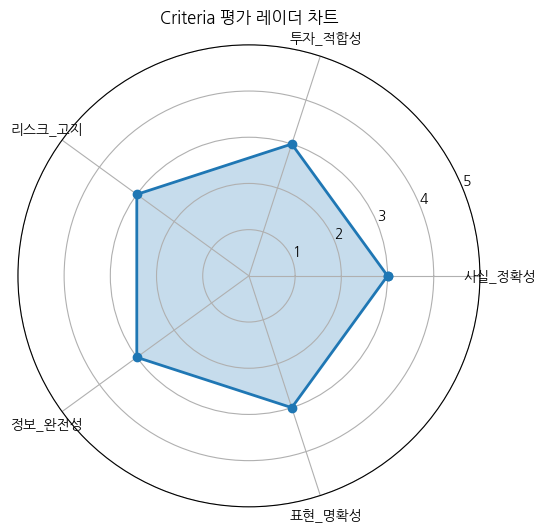

In [28]:
# ✅ 정답
import matplotlib.pyplot as plt

labels = ["사실_정확성", "투자_적합성", "리스크_고지", "정보_완전성", "표현_명확성"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

avg_scores = []
for label in labels:
    scores = criteria_avg.get(label, [3])
    avg_scores.append(np.mean(scores))
values = avg_scores + avg_scores[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, 'o-', linewidth=2)
ax.fill(angles, values, alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 5)
plt.title("Criteria 평가 레이더 차트")
plt.show()

---
## 실습 12: 통합 평가 파이프라인 실행

In [29]:
# 종합 평가 파이프라인
class ETFEvaluationPipeline:
    """ETF 추천 답변 종합 평가 파이프라인"""

    def __init__(self, thresholds=None):
        self.thresholds = thresholds or {
            "ROUGE-1": 0.3,
            "BERTScore": 0.7,
            "LLM_Judge": 15,
        }
        self.results = []

    def evaluate_single(self, query, answer, reference, context):
        """단일 답변 종합 평가"""
        # 텍스트 메트릭
        bleu4 = compute_bleu(reference, answer, max_n=4)
        r1 = rouge_n(reference, answer, 1)["f1"]
        r2 = rouge_n(reference, answer, 2)["f1"]
        rl = rouge_l(reference, answer)["f1"]
        bs = simple_bertscore(reference, answer)

        # LLM 평가
        judge = llm_judge(query, answer, context)
        judge_total = judge.get("총점", 0)

        # 품질 게이트
        gate_results = {}
        gate_results["ROUGE-1"] = r1 >= self.thresholds["ROUGE-1"]
        gate_results["BERTScore"] = bs >= self.thresholds["BERTScore"]
        gate_results["LLM_Judge"] = judge_total >= self.thresholds["LLM_Judge"]

        all_pass = all(gate_results.values())
        any_fail = not all_pass
        critical_fail = not gate_results.get("BERTScore", True)

        if critical_fail:
            status = "🔴 FAIL"
        elif any_fail:
            status = "🟡 WARN"
        else:
            status = "🟢 PASS"

        result = {
            "query": query[:30], "BLEU-4": bleu4,
            "ROUGE-1": r1, "ROUGE-2": r2, "ROUGE-L": rl,
            "BERTScore": bs, "LLM_Judge": judge_total,
            "status": status, "gate": gate_results,
        }
        self.results.append(result)
        return result

    def evaluate_batch(self, eval_data, answer_fn):
        """배치 평가"""
        for item in eval_data:
            answer = answer_fn(item["query"])
            context = "\n".join([c for _, _, c in hybrid_search(item["query"], k=3)])
            self.evaluate_single(item["query"], answer, item["reference"], context)
        return self

    def summary(self):
        """평가 요약"""
        df = pd.DataFrame(self.results)
        print("=== 종합 평가 결과 ===")
        print(df[["query", "BLEU-4", "ROUGE-1", "BERTScore", "LLM_Judge", "status"]].to_string(index=False))
        print(f"\n🟢 PASS: {sum(1 for r in self.results if '🟢' in r['status'])}")
        print(f"🟡 WARN: {sum(1 for r in self.results if '🟡' in r['status'])}")
        print(f"🔴 FAIL: {sum(1 for r in self.results if '🔴' in r['status'])}")
        return df

# 실행
pipeline = ETFEvaluationPipeline()
pipeline.evaluate_batch(
    EVAL_QUERIES[:3],
    lambda q: answers.get(q, ask_etf(q))
)
df = pipeline.summary()

=== 종합 평가 결과 ===
              query   BLEU-4  ROUGE-1  BERTScore  LLM_Judge status
안정적인 배당 ETF를 추천해주세요 0.000000 0.142857   0.750781         25 🟡 WARN
    미국 주식에 투자하고 싶어요 0.193102 0.444444   0.830976         24 🟢 PASS
 원금 손실 위험이 적은 ETF는? 0.000000 0.242424   0.557780         25 🔴 FAIL

🟢 PASS: 1
🟡 WARN: 1
🔴 FAIL: 1


In [30]:
# ✅ 정답
pipeline = ETFEvaluationPipeline()
pipeline.evaluate_batch(EVAL_QUERIES, lambda q: answers.get(q, ask_etf(q)))
df = pipeline.summary()

os.makedirs("project2_data/evaluation", exist_ok=True)
df.to_csv("project2_data/evaluation/evaluation_results.csv", index=False, encoding="utf-8-sig")
print("\n✅ evaluation_results.csv 저장 완료")

=== 종합 평가 결과 ===
              query   BLEU-4  ROUGE-1  BERTScore  LLM_Judge status
안정적인 배당 ETF를 추천해주세요 0.000000 0.142857   0.750735         25 🟡 WARN
    미국 주식에 투자하고 싶어요 0.193102 0.444444   0.831005         24 🟢 PASS
 원금 손실 위험이 적은 ETF는? 0.000000 0.242424   0.558431         25 🔴 FAIL
     반도체 섹터에 투자하려면? 0.136371 0.358974   0.824066         25 🟢 PASS
 인플레이션 헤지 방법이 있을까요? 0.000000 0.470588   0.830666         23 🟢 PASS
  중국 시장에 투자하는 ETF는? 0.000000 0.250000   0.772066         23 🟡 WARN

🟢 PASS: 3
🟡 WARN: 2
🔴 FAIL: 1

✅ evaluation_results.csv 저장 완료


---
## 실습 13: 평가 대시보드 확장

In [31]:
# Gradio 평가 대시보드
import gradio as gr

def evaluate_query(query, reference=""):
    """질의 평가 전체 파이프라인"""
    # 1) 검색 + 리랭킹
    initial = hybrid_search(query, k=7)
    reranked = llm_rerank(query, initial, top_k=3)
    filtered = score_filter(reranked, method="dynamic")

    # 2) 답변 생성
    context = "\n".join([f"[{did}] {c}" for did, _, c in filtered])
    _llm = ChatOpenAI(model=MODEL, temperature=0)
    answer = _llm.invoke([
        SystemMessage(content="ETF 전문가입니다. 검색된 문서만을 근거로 답변하세요."),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {query}")
    ]).content

    # 3) 검색 결과 포맷
    search_info = "📋 검색 결과:\n"
    for did, score, content in filtered:
        search_info += f"  [{did}] score={score}\n"

    # 4) 자동 메트릭 (참조 답변이 있는 경우)
    metrics_info = ""
    if reference.strip():
        b4 = compute_bleu(reference, answer, max_n=4)
        r1 = rouge_n(reference, answer, 1)["f1"]
        rl = rouge_l(reference, answer)["f1"]
        bs = simple_bertscore(reference, answer)
        metrics_info = f"📊 자동 평가:\n  BLEU-4: {b4:.4f}\n  ROUGE-1: {r1:.4f}\n  ROUGE-L: {rl:.4f}\n  BERTScore: {bs:.4f}"
    else:
        metrics_info = "📊 참조 답변을 입력하면 자동 평가가 표시됩니다."

    # 5) LLM-as-Judge
    judge = llm_judge(query, answer, context)
    judge_info = f"🧑‍⚖️ LLM-as-Judge:\n  총점: {judge.get('총점', 'N/A')}/25\n  피드백: {judge.get('피드백', 'N/A')[:200]}"

    return answer, search_info, metrics_info, judge_info

demo = gr.Interface(
    fn=evaluate_query,
    inputs=[
        gr.Textbox(label="질문", placeholder="ETF 관련 질문을 입력하세요"),
        gr.Textbox(label="참조 답변 (선택)", placeholder="자동 평가를 위한 정답"),
    ],
    outputs=[
        gr.Textbox(label="📝 생성된 답변"),
        gr.Textbox(label="🔍 검색 결과"),
        gr.Textbox(label="📊 자동 메트릭"),
        gr.Textbox(label="🧑‍⚖️ LLM 평가"),
    ],
    title="ETF 추천 + 품질 평가 대시보드",
    examples=[
        ["안정적인 배당 ETF를 추천해주세요", "KODEX 배당가치 ETF를 추천합니다. 고배당 가치주에 투자하며 리스크가 낮습니다."],
        ["미국 주식에 투자하고 싶어요", ""],
        ["원금 손실 위험이 적은 ETF는?", ""],
    ]
)

print("✅ Gradio 대시보드 준비 완료")
# demo.launch()  # 주석 해제하여 실행

✅ Gradio 대시보드 준비 완료


In [32]:
# ✅ 정답
def evaluate_query_extended(query, reference=""):
    """질의 평가 전체 파이프라인 (Criteria 포함)"""
    initial = hybrid_search(query, k=7)
    reranked = llm_rerank(query, initial, top_k=3)
    filtered = score_filter(reranked, method="dynamic")

    context = "\n".join([f"[{did}] {c}" for did, _, c in filtered])
    _llm = ChatOpenAI(model=MODEL, temperature=0)
    answer = _llm.invoke([
        SystemMessage(content="ETF 전문가입니다. 검색된 문서만을 근거로 답변하세요."),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {query}")
    ]).content

    search_info = "📋 검색 결과:\n"
    for did, score, content in filtered:
        search_info += f"  [{did}] score={score}\n"

    metrics_info = ""
    if reference.strip():
        b4 = compute_bleu(reference, answer, max_n=4)
        r1 = rouge_n(reference, answer, 1)["f1"]
        rl = rouge_l(reference, answer)["f1"]
        bs = simple_bertscore(reference, answer)
        metrics_info = f"📊 자동 평가:\n  BLEU-4: {b4:.4f}\n  ROUGE-1: {r1:.4f}\n  ROUGE-L: {rl:.4f}\n  BERTScore: {bs:.4f}"
        gate = "🟢 PASS" if bs >= 0.7 else "🔴 FAIL"
        metrics_info += f"\n\n품질 게이트: {gate}"
    else:
        metrics_info = "📊 참조 답변을 입력하면 자동 평가가 표시됩니다."

    judge = llm_judge(query, answer, context)
    judge_total = judge.get("총점", 0)
    judge_info = f"🧑‍⚖️ LLM-as-Judge:\n  총점: {judge_total}/25\n  피드백: {judge.get('피드백', 'N/A')[:200]}"
    judge_info += "\n  게이트: 🟢 PASS" if judge_total >= 15 else "\n  게이트: 🔴 FAIL"

    crit = criteria_evaluation(query, answer, context)
    crit_info = "📋 Criteria 평가:\n"
    for name, r in crit["criteria"].items():
        crit_info += f"  {name}: {r['score']}/5 — {r['reason'][:40]}\n"
    crit_info += f"\n  가중 점수: {crit['weighted_score']:.2f}/5.00 ({crit['normalized']:.0f}점)"

    return answer, search_info, metrics_info, judge_info, crit_info

demo_ext = gr.Interface(
    fn=evaluate_query_extended,
    inputs=[
        gr.Textbox(label="질문", placeholder="ETF 관련 질문을 입력하세요"),
        gr.Textbox(label="참조 답변 (선택)", placeholder="자동 평가를 위한 정답"),
    ],
    outputs=[
        gr.Textbox(label="📝 생성된 답변"),
        gr.Textbox(label="🔍 검색 결과"),
        gr.Textbox(label="📊 자동 메트릭"),
        gr.Textbox(label="🧑‍⚖️ LLM 평가"),
        gr.Textbox(label="📋 Criteria 평가"),
    ],
    title="ETF 추천 + 품질 평가 대시보드 (확장)",
)
print("✅ 확장 대시보드 준비 완료")
# demo_ext.launch()

✅ 확장 대시보드 준비 완료


---
## 실습 14: 체크포인트 저장과 검증

In [ ]:
# Weekend 2 체크포인트 저장
import json, os
from datetime import datetime

os.makedirs("project2_data/checkpoints", exist_ok=True)

# 1. 최종 평가 결과 저장
weekend2_results = {
    "timestamp": datetime.now().isoformat(),
    "version": "2.0",
    "evaluation_metrics": ["BLEU", "ROUGE", "BERTScore", "LLM-as-Judge", "Criteria"],
    "pipeline_config": {
        "search_k": 7,
        "rerank_k": 3,
        "filter_method": "dynamic",
        "model": "gpt-4o-mini",
    },
    "quality_gate_thresholds": {
        "ROUGE-1": 0.3,
        "BERTScore": 0.7,
        "LLM_Judge": 15,
    },
}

with open("project2_data/checkpoints/weekend2_results.json", "w") as f:
    json.dump(weekend2_results, f, ensure_ascii=False, indent=2)

# 2. 답변 캐시 저장
with open("project2_data/checkpoints/weekend2_answers.json", "w") as f:
    json.dump(answers, f, ensure_ascii=False, indent=2)

# 3. 프로젝트 상태 저장
weekend2_state = {
    "weekend": 2,
    "completed": True,
    "achievements": [
        "LLM 기반 리랭킹 파이프라인 구축",
        "스코어 필터링 (고정/동적/갭) 구현",
        "프롬프트 최적화 (기본/최적화/Few-shot)",
        "BLEU, ROUGE, BERTScore 자동 평가",
        "한국어 금융 도메인 토큰화",
        "LLM-as-Judge 평가 파이프라인",
        "Criteria 기반 다차원 평가",
        "종합 평가 파이프라인 + 품질 게이트",
        "Gradio 평가 대시보드",
    ]
}

with open("project2_data/checkpoints/weekend2_state.json", "w") as f:
    json.dump(weekend2_state, f, ensure_ascii=False, indent=2)

print("✅ Weekend 2 체크포인트 저장 완료")
for f_name in ["weekend2_results.json", "weekend2_answers.json", "weekend2_state.json"]:
    print(f"  📁 project2_data/checkpoints/{f_name}")

In [ ]:
# ✅ 정답
report = {
    "weekend1": {"methods": ["FAISS", "BM25", "Hybrid"], "best": "Hybrid"},
    "weekend2": weekend2_state,
}

with open("project2_data/checkpoints/integrated_report.json", "w") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

checklist = [
    ("벡터 스토어", os.path.exists("project2_data/vectorstore/faiss_baseline")),
    ("ETF 문서", os.path.exists("project2_data/raw/etf_documents.json")),
    ("Weekend 2 결과", os.path.exists("project2_data/checkpoints/weekend2_results.json")),
    ("답변 캐시", os.path.exists("project2_data/checkpoints/weekend2_answers.json")),
    ("통합 리포트", os.path.exists("project2_data/checkpoints/integrated_report.json")),
]
print("📋 파일 체크리스트:")
for name, exists in checklist:
    status = "✅" if exists else "❌"
    print(f"  {status} {name}")